# Prelude

In [1]:
import numpy
import matplotlib
import seaborn
import pandas

from matplotlib import pyplot
seaborn.set()

In [2]:
cd ~/TP/connections

/home/mfixman/Dropbox/continuous/TP/connections


# Getting Data

In [3]:
!ls results

DefaultFull.csv  NoModel.csv  SmallFull.csv


In [27]:
def load(filename):
    result = pandas.read_csv(filename)
    result = result.loc[lambda x: x.event.isna()]
    result[result.select_dtypes('float').columns].apply(pandas.to_numeric, downcast = 'integer')
    result['proved'] = result.proved == 'true'
    result['problem'] = result.problem.str.extract(r'([^\/]*)$')

    todrop = ['event', 'part', 'policy', 'mode', 'guidance_fallback', 'parseable', 'error', 'problems', 'proved_seconds_total', 'proved_seconds_mean', 'axioms', 'kept_axioms', 'prediction_seconds', 'proof_size', 'seed']
    result.drop(todrop, axis = 1, inplace = True)

    result.set_index('problem', inplace = True)
    return result

In [28]:
nomodel = load('results/NoModel.csv')
sull = load('results/SmallFull.csv')
dull = load('results/DefaultFull.csv')

# Testing

In [50]:
total_count = 2889

In [51]:
nomodel_ = nomodel.rename(columns = lambda x: x + '_nomodel')
sull_ = sull.rename(columns = lambda x: x + '_small')
dull_ = dull.rename(columns = lambda x: x + '_full')

merged = nomodel_.merge(
    sull_,
    left_index = True,
    right_index = True,
).merge(
    dull_,
    left_index = True,
    right_index = True,
)

merged

,outcome_nomodel,proved_nomodel,seconds_nomodel,steps_nomodel,outcome_small,proved_small,seconds_small,steps_small,outcome_full,proved_full,seconds_full,steps_full
problem,,,,,,,,,,,,
ALG313-1.p,DeclaredSatisfiable,False,43.437033,NaN,DeclaredSatisfiable,False,5.108007,NaN,DeclaredSatisfiable,False,5.686564,NaN
ALG307-1.p,DeclaredSatisfiable,False,43.447103,NaN,DeclaredSatisfiable,False,5.108894,NaN,DeclaredSatisfiable,False,5.692522,NaN
ALG319-1.p,DeclaredSatisfiable,False,0.010413,NaN,DeclaredSatisfiable,False,0.002245,NaN,DeclaredSatisfiable,False,0.008256,NaN
ALG317-1.p,DeclaredSatisfiable,False,43.470687,NaN,DeclaredSatisfiable,False,5.107148,NaN,DeclaredSatisfiable,False,5.691520,NaN
ALG330-1.p,DeclaredSatisfiable,False,0.042170,NaN,DeclaredSatisfiable,False,0.004350,NaN,DeclaredSatisfiable,False,0.008227,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
TOP043+2.p,Timeout,False,120.005093,NaN,Timeout,False,120.002389,NaN,Timeout,False,120.014891,NaN
TOP043+3.p,Timeout,False,120.000856,NaN,Timeout,False,120.005054,NaN,Timeout,False,120.001187,NaN
TOP045+1.p,Timeout,False,120.001650,NaN,Timeout,False,120.001809,NaN,Timeout,False,120.000846,NaN


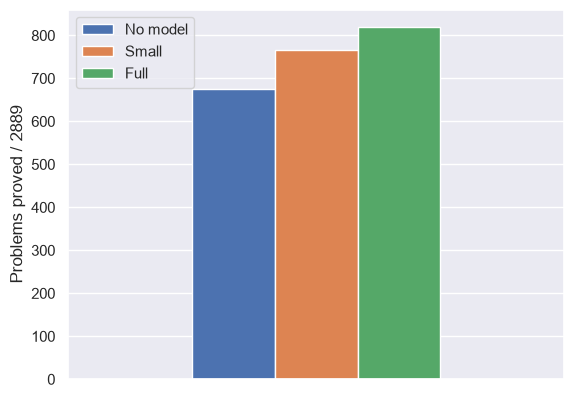

In [76]:
counts = pandas.DataFrame({
      "No model": [nomodel.proved.sum()],
      "Small": [sull.proved.sum()],
      "Full": [dull.proved.sum()],
  })

counts.plot.bar(xlabel = "", xticks = [], ylabel = f"Problems proved / {total_count}");
pyplot.savefig('plots/total_problems.png')

In [ ]:
models = {"No model": nomodel, "Small": sull, "Full": dull}

def plot_solved_by(column, limits, labels, legend_title):
    counts = pandas.DataFrame({
        name: pandas.cut(
            data.loc[data.proved, column],
            bins = [-numpy.inf, *limits, numpy.inf],
            labels = labels,
        ).value_counts(sort = False)
        for name, data in models.items()
    }).T

    counts = counts.loc[:, counts.any(axis = 0)]
    with seaborn.axes_style("darkgrid"):
        fig, ax = pyplot.subplots(figsize = (2.2, 3.8), layout = "constrained")
        counts.plot.bar(
            ax = ax,
            stacked = True,
            color = seaborn.color_palette(n_colors = counts.shape[1]),
            rot = 0,
            xlabel = "",
            ylabel = "Problems solved",
            width = 0.7,
        )

    ax.set_ylim(0, 900)
    ax.tick_params(axis = "both", labelsize = 8)
    ax.yaxis.label.set_size(9)
    ax.grid(axis = "x", visible = False)
    ax.legend(
        title = legend_title,
        loc = "lower center",
        bbox_to_anchor = (0.5, 1.02),
        ncol = 2,
        fontsize = 7,
        title_fontsize = 8,
        frameon = False,
        columnspacing = 0.8,
        handlelength = 1.2,
    )

    seaborn.despine(ax = ax)
    return fig


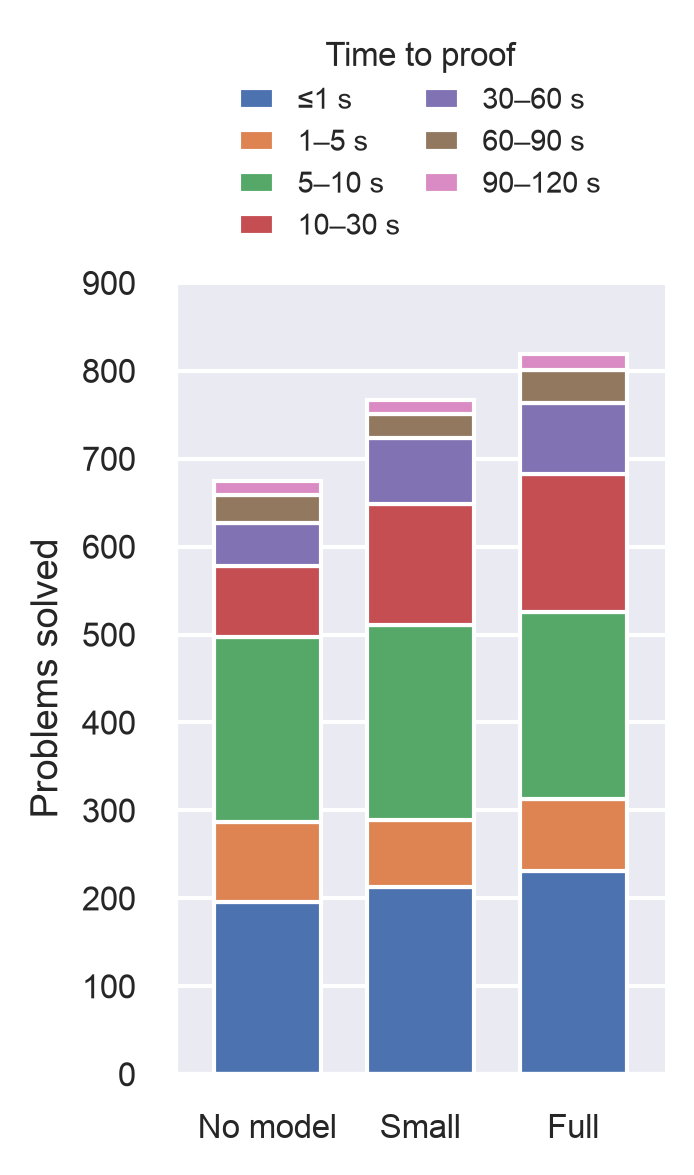

In [ ]:
time_fig = plot_solved_by(
    "seconds",
    [1, 5, 10, 30, 60, 90, 120],
    ["≤1 s", "1–5 s", "5–10 s", "10–30 s", "30–60 s", "60–90 s", "90–120 s", ">120 s"],
    "Time to proof",
)

for extension in ("png", "pdf"):
    time_fig.savefig(f"plots/time_plot.{extension}", dpi = 300, bbox_inches = "tight")

pyplot.show()


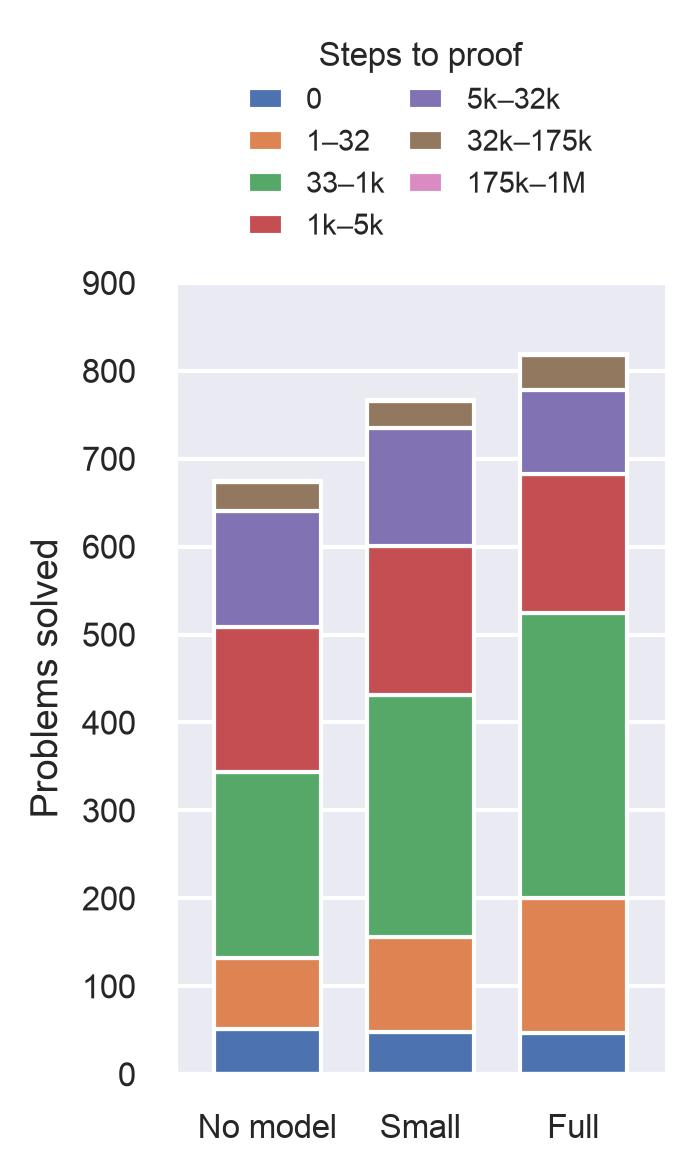

In [ ]:
steps_fig = plot_solved_by(
    "steps",
    [0, 32, 1000, 5000, 32000, 175000, 1000000],
    ["0", "1–32", "33–1k", "1k–5k", "5k–32k", "32k–175k", "175k–1M", ">1M"],
    "Steps to proof",
)

for extension in ("png", "pdf"):
    steps_fig.savefig(f"plots/steps_plot.{extension}", dpi = 300, bbox_inches = "tight")

pyplot.show()


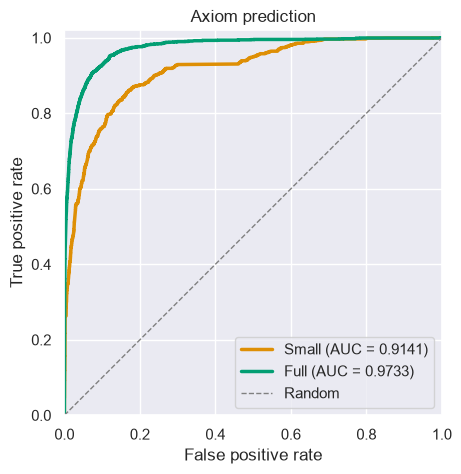

In [79]:
curves = {
  "Small": "results/roc_small_epoch142_part8.csv",
  "Full": "results/roc_full_epoch119_part8.csv",
}

fig, ax = pyplot.subplots(figsize = (6, 5))

for (name, filename), colour in zip(curves.items(), seaborn.color_palette("colorblind", 3)[1:]):
  curve = pandas.read_csv(filename)
  auc = numpy.trapezoid(curve.tpr, curve.fpr)
  ax.plot(
      curve.fpr,
      curve.tpr,
      color = colour,
      linewidth = 2.5,
      label = f"{name} (AUC = {auc:.4f})",
  )

ax.plot([0, 1], [0, 1], "--", color = "grey", linewidth = 1, label = "Random")
ax.set(
  xlabel = "False positive rate",
  ylabel = "True positive rate",
  title = "Axiom prediction",
  xlim = (0, 1),
  ylim = (0, 1.02),
  aspect = "equal",
)

ax.legend(loc = "lower right", frameon = True)

pyplot.savefig('plots/roc_curve.png', dpi = 300, bbox_inches = 'tight')

In [73]:
pwd

'/home/mfixman/Dropbox/continuous/TP/connections'